# Curve-fit sandbox
This notebook recreates the functional-group preprocessing fits for a single marker, using **the exact same optimiser setup and model set** as the production pipeline (`functional_groups_inputs.py`).

Only the two models that remain active in the pipeline (`dlogistic` and `rise_fall`) are evaluated, and SciPy's `least_squares` is configured with the same `loss`, `f_scale`, solver, and iteration limits as in the script. Edit the cells below if you want to experiment, but they now default to the pipeline behaviour for apples-to-apples comparisons.

Joint fits use the pipeline's λ smoothness penalty between neighbouring GFP bins; tune `LAMBDA_SMOOTH` (set to 0 for independent bins). A second regulariser (`LAMBDA_EULER`) enforces consistency between the model's analytic derivative (forward-Euler integrated) and the observed trajectory.


In [10]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path
from typing import Callable, Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import least_squares

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("Run this notebook from within the project repository.")

for candidate in (PROJECT_ROOT, PROJECT_ROOT / "src"):
    as_str = str(candidate)
    if as_str not in sys.path:
        sys.path.insert(0, as_str)

sns.set_theme(style="whitegrid")

from experimental.data_prep.functional_groups_inputs import (
    DEFAULT_PROTEINS,
    assign_gfp_bins,
)
DEFAULT_PROTEINS = ['p-ERK1-2']

In [11]:
# --- configuration -------------------------------------------------------
RAW_TIMECOURSE_PATH = PROJECT_ROOT / "data/experimental/raw/lun_2019.csv"
MARKER_OF_INTEREST = "DUSP4"
PLOT_PROTEIN = "p-ERK1-2"
GFP_BINS = 50  # only used when FORCE_REBIN=True
FORCE_REBIN = False
MIN_POINTS = 5
MIN_R2 = 0.95
LAMBDA_SMOOTH = 1.0  # smoothness λ between neighbouring GFP bins (0 disables coupling)
LAMBDA_EULER = 0.0  # weight for Euler-integrated derivative vs observed (0 disables)
EXTRA_TIMES = (1.0, 3.0)  # minutes
DENSE_STEP = 1.0  # minutes
SELECTED_BINS = None  # e.g. [0, 5, 10]


In [12]:
raw_df = pd.read_csv(RAW_TIMECOURSE_PATH)
required_cols = {"marker", "GFP", "timepoint"}
missing = required_cols - set(raw_df.columns)
if missing:
    raise ValueError(f"Time-course CSV is missing: {sorted(missing)}")

raw_df = raw_df.copy()
raw_df["marker"] = raw_df["marker"].astype(str)
raw_df["timepoint"] = pd.to_numeric(raw_df["timepoint"], errors="coerce")
raw_df = raw_df.dropna(subset=["timepoint"])

if FORCE_REBIN or ("GFP_bin" not in raw_df.columns):
    print(f"Assigning {GFP_BINS} GFP bins from scratch")
    raw_df["GFP_bin"] = assign_gfp_bins(raw_df, GFP_BINS)
else:
    print("Using existing GFP_bin column")

raw_df = raw_df.dropna(subset=["GFP_bin"])
raw_df["GFP_bin"] = raw_df["GFP_bin"].astype(int)

marker_df = raw_df[raw_df["marker"] == MARKER_OF_INTEREST].copy()
if marker_df.empty:
    raise ValueError(f"Marker {MARKER_OF_INTEREST!r} not present in {RAW_TIMECOURSE_PATH}")

raw_timepoints = np.sort(marker_df["timepoint"].unique())
gfp_bins = sorted(marker_df["GFP_bin"].unique())
print(f"Loaded {len(marker_df):,} rows for {MARKER_OF_INTEREST} across {len(gfp_bins)} GFP bins")
proteins = [p for p in DEFAULT_PROTEINS if p in marker_df.columns]
if not proteins:
    raise ValueError("None of DEFAULT_PROTEINS are present in the dataset.")


Using existing GFP_bin column
Loaded 235 rows for DUSP4 across 47 GFP bins


In [13]:
# --- identical model set + optimiser -------------------------------------
import numpy as np
import pandas as pd
import warnings
from typing import Dict, Callable, Tuple, List, Sequence
from scipy.optimize import least_squares

def _clip_exp(z: np.ndarray) -> np.ndarray:
    return np.exp(np.clip(z, -50.0, 50.0))

# Only the two models that remain active in the pipeline
def _rise_fall(t, B, A, tau_T, tau_S):
    tau_T = max(tau_T, 1e-3)
    tau_S = max(tau_S, 1e-3)
    e1 = _clip_exp(-t / tau_T)
    e2 = _clip_exp(-t / tau_S)
    return B + A * (1.0 - e1) * e2

def _p0_rise_fall(t, y):
    B0 = float(np.nanmin(y))
    A0 = max(float(np.nanmax(y) - B0), 1e-3)
    return [B0, A0, 5.0, 10.0], ([-np.inf, 0.0, 3.0, 1e-3], [np.inf, np.inf, 1e3, 1e3]), 4

def _dlogistic(t, B, A1, A2, t1, t2, k, m):
    """
    Difference of logistics with a linear tail:
    y = B + A1*s1(t) - A2*s2(t) + m*t
    """
    k = max(k, 1e-6)
    s1 = 1.0 / (1.0 + _clip_exp(-(t - t1) * k))
    s2 = 1.0 / (1.0 + _clip_exp(-(t - t2) * k))
    return B + A1 * s1 - A2 * s2 + m * t


def _p0_dlogistic(t, y):
    """
    Initialisation + bounds for dlogistic+linear.
    """
    B0 = float(np.nanmin(y))
    ymax = float(np.nanmax(y))
    span = max(ymax - B0, 1e-3)
    t_med = float(np.median(t))

    # ---- initial guess ----
    p0 = [
        B0,            # B
        0.7 * span,    # A1
        0.7 * span,    # A2
        t_med * 0.7,   # t1
        t_med * 1.3,   # t2
        0.2,           # k
        0.0            # m  (start flat)
    ]

    # ---- bounds ----
    # Allow a modest slope for the tail: |m| <= slope_max
    slope_max = 0.05  # adjust if needed

    lower = [
        -np.inf,   # B
        0.0,       # A1
        0.0,       # A2
        -np.inf,   # t1
        -np.inf,   # t2
        0.02,      # k
        -slope_max # m
    ]
    upper = [
        np.inf,
        np.inf,
        np.inf,
        np.inf,
        np.inf,
        0.6,        # k
        slope_max   # m
    ]

    return p0, (lower, upper), 7   # 7 parameters now

def _rise_fall_derivative(t, B, A, tau_T, tau_S):
    tau_T = max(tau_T, 1e-3)
    tau_S = max(tau_S, 1e-3)
    e1 = _clip_exp(-t / tau_T)
    e2 = _clip_exp(-t / tau_S)
    return A * e2 * (e1 / tau_T - (1.0 - e1) / tau_S)

def _dlogistic_derivative(t, B, A1, A2, t1, t2, k, m):
    k = max(k, 1e-6)
    s1 = 1.0 / (1.0 + _clip_exp(-(t - t1) * k))
    s2 = 1.0 / (1.0 + _clip_exp(-(t - t2) * k))
    ds1 = k * s1 * (1.0 - s1)
    ds2 = k * s2 * (1.0 - s2)
    return A1 * ds1 - A2 * ds2 + m

PREDICTORS: Dict[str, Callable] = {"dlogistic": _dlogistic, "rise_fall": _rise_fall}
PREDICTOR_DERIVS: Dict[str, Callable] = {"dlogistic": _dlogistic_derivative, "rise_fall": _rise_fall_derivative}
INIT_FUNCS = {"dlogistic": _p0_dlogistic, "rise_fall": _p0_rise_fall}

# -------------------------------------------------------------------------
# Evaluation utilities
# -------------------------------------------------------------------------

def _evaluate_fit(y_true: np.ndarray, y_pred: np.ndarray, k: int) -> Tuple[float, float, float]:
    """Single-trajectory RSS, R², AICc."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rss = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.nanmean(y_true)) ** 2))
    r2 = 1.0 - rss / ss_tot if ss_tot > 0 else float("nan")
    n = len(y_true)
    if n <= k + 1 or rss <= 0:
        aicc = float("inf")
    else:
        aicc = n * np.log(rss / n) + 2 * k + (2 * k * (k + 1)) / max(n - k - 1, 1)
    return rss, r2, aicc

def _evaluate_fit_multi(all_y_true: List[np.ndarray],
                        all_y_pred: List[np.ndarray],
                        k_total: int) -> Tuple[float, float, float]:
    """Global RSS, R², AICc across multiple bins."""
    y_true = np.concatenate([np.asarray(yb, dtype=float).ravel() for yb in all_y_true])
    y_pred = np.concatenate([np.asarray(yp, dtype=float).ravel() for yp in all_y_pred])
    rss = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.nanmean(y_true)) ** 2))
    r2 = 1.0 - rss / ss_tot if ss_tot > 0 else float("nan")
    n = len(y_true)
    if n <= k_total + 1 or rss <= 0:
        aicc = float("inf")
    else:
        aicc = n * np.log(rss / n) + 2 * k_total + (2 * k_total * (k_total + 1)) / max(n - k_total - 1, 1)
    return rss, r2, aicc

# -------------------------------------------------------------------------
# Original per-bin fitter (kept for reference / other uses)
# -------------------------------------------------------------------------

def fit_models_for_protein(t: np.ndarray, y: np.ndarray) -> Dict:
    """Fit both models independently for a single trajectory."""
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(y)
    if valid.sum() < MIN_POINTS:
        return {}
    t = t[valid]
    y = y[valid]
    candidates = []
    for name in ("dlogistic", "rise_fall"):
        init_fn = INIT_FUNCS[name]
        try:
            p0, bounds, k = init_fn(t, y)
            result = least_squares(
                lambda params: PREDICTORS[name](t, *params) - y,
                p0,
                bounds=bounds,
                loss="huber",
                f_scale=1.0,
                method="trf",
                max_nfev=200,
            )
            popt = result.x
            _, r2, aicc = _evaluate_fit(y, PREDICTORS[name](t, *popt), len(popt))
            candidates.append(
                {"name": name, "params": popt, "r2": float(r2), "aicc": float(aicc)}
            )
        except Exception as exc:
            warnings.warn(f"{name} fit failed: {exc}")
    if not candidates:
        return {}
    candidates.sort(key=lambda d: d["r2"], reverse=True)
    best = candidates[0]
    if len(candidates) > 1:
        eps = 1e-3
        tied = [cand for cand in candidates if abs(cand["r2"] - candidates[0]["r2"]) < eps]
        if len(tied) > 1:
            best = min(tied, key=lambda d: d["aicc"])
    return best

# -------------------------------------------------------------------------
# JOINT FITTING ACROSS GFP BINS (option 1)
# -------------------------------------------------------------------------

def _joint_residuals(params_flat: np.ndarray,
                     all_t: List[np.ndarray],
                     all_y: List[np.ndarray],
                     model_fn: Callable,
                     deriv_fn: Callable,
                     k: int,
                     lam: float,
                     lam_euler: float) -> np.ndarray:
    """
    Residuals for joint optimisation across bins:

    - data residuals for each bin
    - sqrt(lam) * (theta_{b+1} - theta_b) for smoothness
    - sqrt(lam_euler) * (Euler-integrated derivative - observed) per bin
    """
    B = len(all_t)
    residuals: List[np.ndarray] = []

    # data + Euler residuals per bin
    for b in range(B):
        theta_b = params_flat[b * k:(b + 1) * k]
        t_b = all_t[b]
        y_b = all_y[b]
        y_pred = model_fn(t_b, *theta_b)
        residuals.append(y_pred - y_b)

        if lam_euler > 0.0 and len(t_b) > 1:
            dt = np.diff(t_b)
            deriv_vals = deriv_fn(t_b[:-1], *theta_b)
            y_euler = np.empty_like(t_b, dtype=float)
            y_euler[0] = y_b[0]
            y_euler[1:] = y_euler[0] + np.cumsum(dt * deriv_vals)
            residuals.append(np.sqrt(lam_euler) * (y_euler[1:] - y_b[1:]))

    # smoothness residuals between neighbouring bins
    if lam > 0.0 and B > 1:
        sqrt_lam = np.sqrt(lam)
        for b in range(B - 1):
            theta_b = params_flat[b * k:(b + 1) * k]
            theta_bp1 = params_flat[(b + 1) * k:(b + 2) * k]
            diff = sqrt_lam * (theta_bp1 - theta_b)
            residuals.append(diff)

    return np.concatenate([r.ravel() for r in residuals])

def fit_models_for_protein_joint(all_t: List[np.ndarray],
                                 all_y: List[np.ndarray],
                                 lam: float = 1.0,
                                 lam_euler: float = 0.0,
                                 model_names: Tuple[str, ...] = ("dlogistic", "rise_fall")) -> Dict:
    """
    Jointly fit all GFP bins for a single protein.
    Returns best model dict including per-bin R² values.
    """
    # Filter out bins with too few valid points
    filtered_t: List[np.ndarray] = []
    filtered_y: List[np.ndarray] = []
    bin_indices: List[int] = []

    for idx, (t_raw, y_raw) in enumerate(zip(all_t, all_y)):
        t_raw = np.asarray(t_raw, dtype=float)
        y_raw = np.asarray(y_raw, dtype=float)
        valid = np.isfinite(y_raw)
        if valid.sum() < MIN_POINTS:
            continue
        filtered_t.append(t_raw[valid])
        filtered_y.append(y_raw[valid])
        bin_indices.append(idx)

    if not filtered_t:
        return {}

    all_t = filtered_t
    all_y = filtered_y
    B = len(all_t)

    candidates = []

    for name in model_names:
        init_fn = INIT_FUNCS[name]
        try:
            # Build stacked initial params and bounds
            p0_list: List[float] = []
            lower_list: List[float] = []
            upper_list: List[float] = []
            k = None

            for t_b, y_b in zip(all_t, all_y):
                p0_b, bounds_b, k_b = init_fn(t_b, y_b)
                if k is None:
                    k = k_b
                elif k != k_b:
                    raise RuntimeError("Parameter dimension mismatch between bins.")
                p0_list.extend(p0_b)
                lo, hi = bounds_b
                lower_list.extend(lo)
                upper_list.extend(hi)

            assert k is not None
            p0 = np.asarray(p0_list, dtype=float)
            bounds = (np.asarray(lower_list, dtype=float),
                      np.asarray(upper_list, dtype=float))

            result = least_squares(
                _joint_residuals,
                p0,
                bounds=bounds,
                args=(all_t, all_y, PREDICTORS[name], PREDICTOR_DERIVS[name], k, lam, lam_euler),
                loss="huber",
                f_scale=1.0,
                method="trf",
                max_nfev=1000,
            )

            params_flat = result.x

            # Global fit statistics
            preds: List[np.ndarray] = []
            for b in range(B):
                theta_b = params_flat[b * k:(b + 1) * k]
                preds.append(PREDICTORS[name](all_t[b], *theta_b))
            _, r2_global, aicc_global = _evaluate_fit_multi(all_y, preds, k_total=k * B)

            candidates.append(
                {
                    "name": name,
                    "params_flat": params_flat,
                    "k": k,
                    "r2": float(r2_global),
                    "aicc": float(aicc_global),
                    "bin_indices": bin_indices,
                }
            )
        except Exception as exc:
            warnings.warn(f"Joint {name} fit failed: {exc}")

    if not candidates:
        return {}

    # Choose best by global R² then AICc
    candidates.sort(key=lambda d: d["r2"], reverse=True)
    best = candidates[0]
    if len(candidates) > 1:
        eps = 1e-3
        tied = [c for c in candidates if abs(c["r2"] - candidates[0]["r2"]) < eps]
        if len(tied) > 1:
            best = min(tied, key=lambda d: d["aicc"])

    # --- NEW: per-bin R² ---------------------------------------------
    k = best["k"]
    params_flat = best["params_flat"]
    r2_per_bin: List[float] = []

    for b in range(len(all_t)):
        theta_b = params_flat[b * k:(b + 1) * k]
        y_true_b = all_y[b]
        y_pred_b = PREDICTORS[best["name"]](all_t[b], *theta_b)
        _, r2_b, _ = _evaluate_fit(y_true_b, y_pred_b, k)
        r2_per_bin.append(float(r2_b))

    best["r2_per_bin"] = r2_per_bin
    # ------------------------------------------------------------------

    return best

def fit_marker_bins_pipeline(
    marker: str,
    gfp_bins: Sequence[int],
    data_per_bin: Dict[int, pd.DataFrame],
    timepoints: np.ndarray,
    dense_times: np.ndarray,
    lam: float = 1.0,
    lam_euler: float = 0.0,
) -> Tuple[List[dict], List[dict], Dict[int, Dict[str, Dict[str, float]]]]:
    """
    Jointly fit all GFP bins for all proteins of a marker.

    Returns
    -------
    fits, dense_fits, metadata_per_bin

    metadata_per_bin[gfp_bin][protein] = {
        "model": ...,
        "r2":    per-bin R²,
        "r2_global": global R² across bins,
        "lam":   lam,
        "lam_euler": lam_euler,
    }
    """
    fits: List[dict] = []
    dense_fits: List[dict] = []
    metadata_per_bin: Dict[int, Dict[str, Dict[str, float]]] = {}

    x_full = np.asarray(timepoints, dtype=float)
    dense_grid = np.unique(np.concatenate([x_full, dense_times]).astype(float))

    for protein in proteins:
        # Collect trajectories in GFP_bin order
        all_t: List[np.ndarray] = []
        all_y: List[np.ndarray] = []
        for b in gfp_bins:
            df_bin = data_per_bin[b]
            series = df_bin[protein].to_numpy(dtype=float)
            all_t.append(x_full)
            all_y.append(series)

        best = fit_models_for_protein_joint(all_t, all_y, lam=lam, lam_euler=lam_euler)
        if not best:
            continue

        model_name = best["name"]
        params_flat = best["params_flat"]
        k = best["k"]
        used_bin_indices = best["bin_indices"]
        r2_global = best["r2"]
        r2_per_bin = best.get("r2_per_bin", [r2_global] * len(used_bin_indices))

        model_fn = PREDICTORS[model_name]

        # reconstruct per-bin parameters and generate curves
        for local_idx, theta_start in enumerate(range(0, len(params_flat), k)):
            theta_b = params_flat[theta_start:theta_start + k]

            # map local index back to actual GFP_bin ID
            bin_pos = used_bin_indices[local_idx]
            gfp_bin = int(gfp_bins[bin_pos])

            curve_main = model_fn(x_full, *theta_b)
            deriv_main = np.gradient(curve_main, x_full) if len(x_full) > 1 else np.zeros_like(curve_main)
            curve_dense = model_fn(dense_grid, *theta_b)

            # --- metadata for THIS curve (bin + protein) ---------------
            meta_bin = metadata_per_bin.setdefault(gfp_bin, {})
            meta_prot = meta_bin.setdefault(protein, {})
            meta_prot["model"] = model_name
            meta_prot["r2"] = float(r2_per_bin[local_idx])   # per-bin R²
            meta_prot["r2_global"] = float(r2_global)        # global R² (optional)
            meta_prot["lam"] = float(lam)
            meta_prot["lam_euler"] = float(lam_euler)
            # -----------------------------------------------------------

            for t_val, y_fit, y_deriv in zip(x_full, curve_main, deriv_main):
                fits.append(
                    {
                        "marker": marker,
                        "GFP_bin": gfp_bin,
                        "protein": protein,
                        "timepoint": float(t_val),
                        "fit": float(y_fit),
                        "derivative": float(y_deriv),
                    }
                )

            for t_val, y_fit in zip(dense_grid, curve_dense):
                dense_fits.append(
                    {
                        "marker": marker,
                        "GFP_bin": gfp_bin,
                        "protein": protein,
                        "timepoint": float(t_val),
                        "fit": float(y_fit),
                    }
                )

    return fits, dense_fits, metadata_per_bin


In [14]:

print(f"Joint fit smoothness λ={LAMBDA_SMOOTH} (0 disables coupling); Euler λ={LAMBDA_EULER} (0 disables)")

dense_timepoints = np.arange(
    np.floor(raw_timepoints.min()),
    np.ceil(raw_timepoints.max()) + DENSE_STEP,
    DENSE_STEP,
)

fit_records: List[dict] = []
dense_fit_records: List[dict] = []
bin_metadata: Dict[int, Dict[str, Dict[str, float]]] = {}
skipped_bins: List[Tuple[int, str]] = []

# ------------------------------------------------------------------
# 1) Build per-bin aggregated trajectories (same as before)
# ------------------------------------------------------------------
data_per_bin: Dict[int, pd.DataFrame] = {}

for gfp_bin in gfp_bins:
    measurements = marker_df[marker_df["GFP_bin"] == gfp_bin]

    if measurements.empty:
        skipped_bins.append((int(gfp_bin), "no measurements"))
        continue

    grouped = (
        measurements
        .groupby("timepoint")[proteins]
        .mean()
        .reindex(raw_timepoints)
    )
    data_per_bin[int(gfp_bin)] = grouped

if not data_per_bin:
    print("No bins with data, nothing to fit.")
else:
    # keep only bins that actually have data, in sorted order
    bins_with_data = sorted(data_per_bin.keys())

    # ------------------------------------------------------------------
    # 2) Joint fit across ALL bins (option 1)
    # ------------------------------------------------------------------
    joint_fits, joint_dense_fits, meta_per_bin = fit_marker_bins_pipeline(
        marker=MARKER_OF_INTEREST,
        gfp_bins=bins_with_data,
        data_per_bin=data_per_bin,
        timepoints=raw_timepoints,
        dense_times=dense_timepoints,
        lam=LAMBDA_SMOOTH,
        lam_euler=LAMBDA_EULER,
    )

    if not joint_fits:
        # fitter failed completely
        for b in bins_with_data:
            skipped_bins.append((b, "no converged joint fit"))
    else:
        # ------------------------------------------------------------------
        # 3) Per-bin quality check on p-ERK1-2, then filter fits
        # ------------------------------------------------------------------
        good_bins: set[int] = set()

        for b in bins_with_data:
            # meta_per_bin[b] should be { protein_name: { "r2": ..., ... } }
            erk_meta = (meta_per_bin.get(b) or {}).get("p-ERK1-2") or {}
            r2_erk = erk_meta.get("r2")  # <-- per-curve R² for this bin

            if r2_erk is None or not np.isfinite(r2_erk) or r2_erk < MIN_R2:
                skipped_bins.append((b, f"p-ERK1-2 R²={r2_erk}"))
            else:
                good_bins.add(b)
                bin_metadata[b] = meta_per_bin[b]

        # Now keep ONLY fits for bins that passed the R² filter
        if good_bins:
            fit_records.extend(
                rec for rec in joint_fits
                if int(rec["GFP_bin"]) in good_bins
            )
            dense_fit_records.extend(
                rec for rec in joint_dense_fits
                if int(rec["GFP_bin"]) in good_bins
            )
        # if good_bins is empty, you'll see "Fitted 0 bins"

print(f"Fitted {len(bin_metadata)} bins (skipped {len(skipped_bins)}).")

Joint fit smoothness λ=1.0 (0 disables coupling); Euler λ=0.0 (0 disables)
Fitted 47 bins (skipped 0).


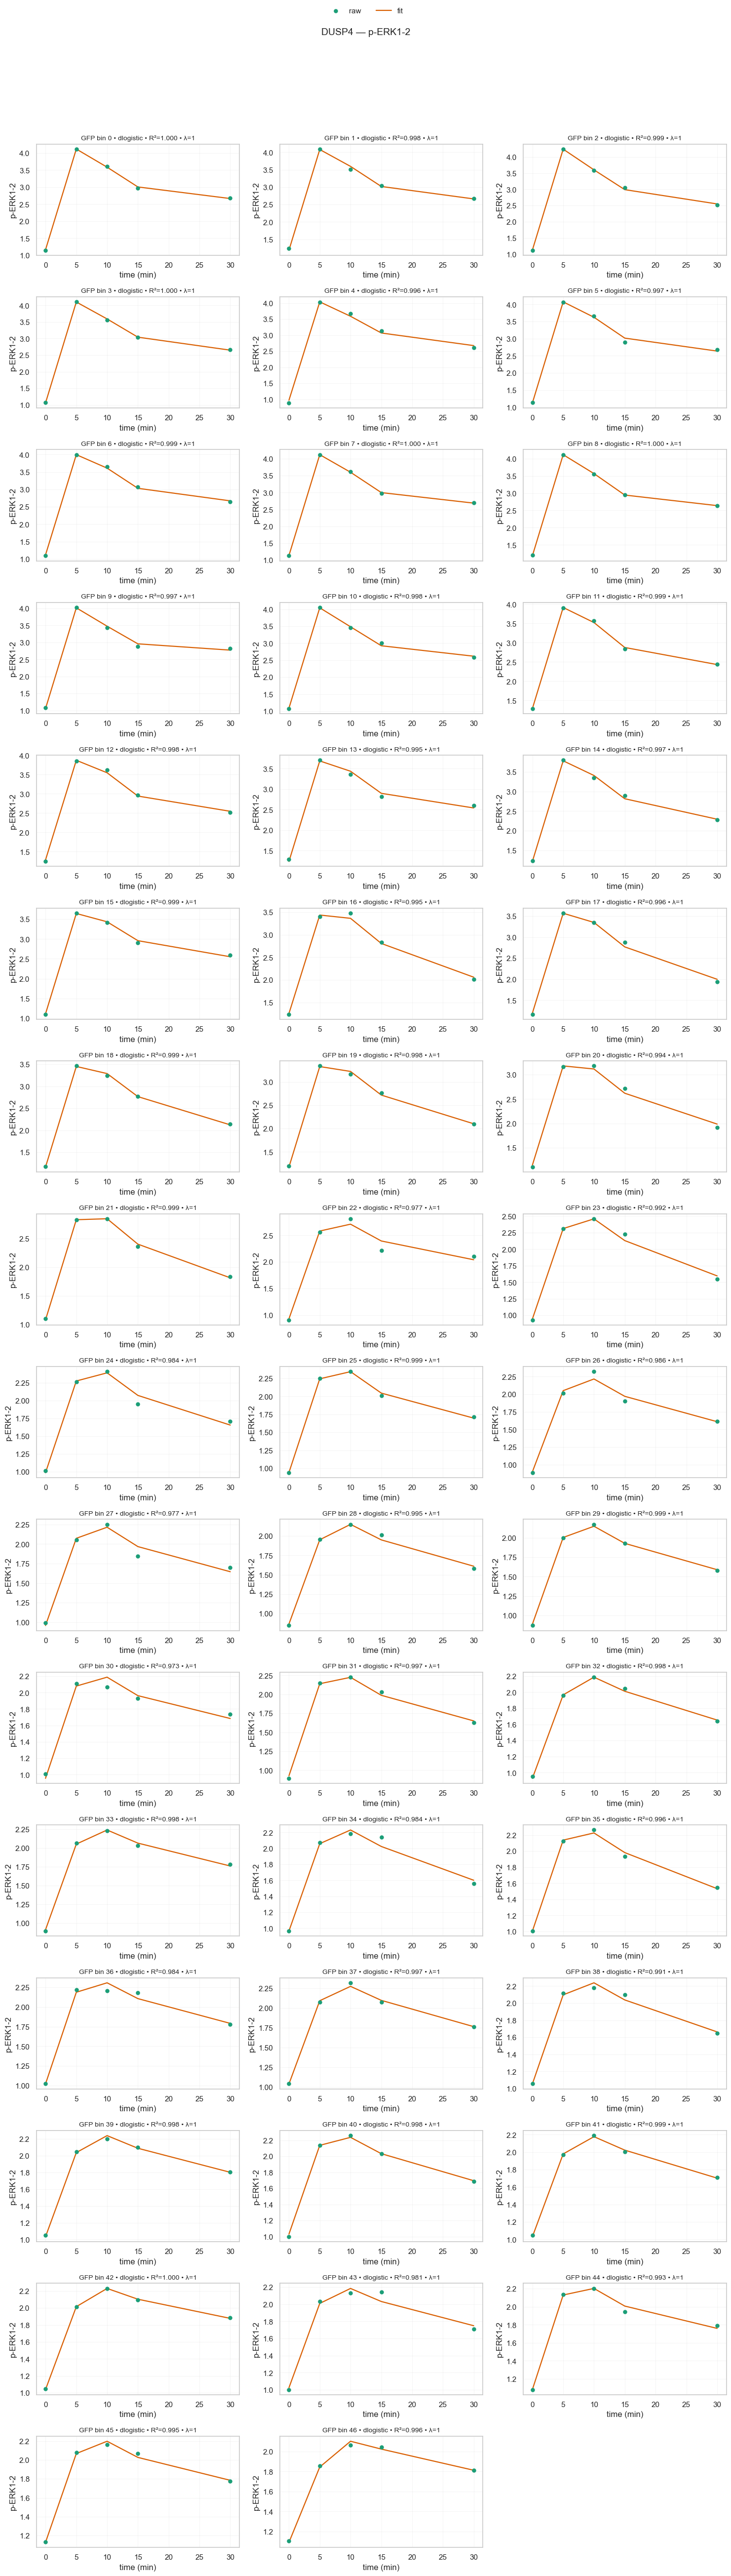

In [15]:
raw_long = (
    marker_df
    .groupby(["GFP_bin", "timepoint"])[proteins]
    .mean()
    .reset_index()
    .melt(id_vars=["GFP_bin", "timepoint"], var_name="protein", value_name="signal")
)
fit_long = pd.DataFrame(fit_records) if fit_records else pd.DataFrame(columns=[
    "marker", "GFP_bin", "timepoint", "protein", "fit", "derivative"
])
dense_fit_long = pd.DataFrame(dense_fit_records) if dense_fit_records else pd.DataFrame(columns=[
    "marker", "GFP_bin", "timepoint", "protein", "fit"
])

def format_bin_label(bin_id: int, protein: str) -> str:
    meta = bin_metadata.get(bin_id, {}).get(protein, {})
    model = meta.get("model") or "unknown"
    lam = meta.get("lam")
    lam_text = f" • λ={lam:.2g}" if lam is not None and np.isfinite(lam) else ""
    r2 = meta.get("r2")
    if r2 is not None and np.isfinite(r2):
        return f"GFP bin {bin_id} • {model} • R²={r2:.3f}{lam_text}"
    return f"GFP bin {bin_id} • {model} • R²=NA{lam_text}"

def plot_per_bin(protein: str, bins: List[int] | None = None) -> None:
    bins = bins or list(bin_metadata.keys())
    if not bins:
        print("No fitted bins available.")
        return
    subset = sorted(bins if SELECTED_BINS is None else [b for b in bins if b in SELECTED_BINS])
    if not subset:
        print("SELECTED_BINS filtered away all bins.")
        return
    ncols = min(3, len(subset))
    nrows = int(np.ceil(len(subset) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.4 * nrows), squeeze=False)
    axes_flat = axes.flatten()
    for ax, bin_id in zip(axes_flat, subset):
        raw_slice = raw_long[(raw_long["protein"] == protein) & (raw_long["GFP_bin"] == bin_id)]
        fit_slice = fit_long[(fit_long["protein"] == protein) & (fit_long["GFP_bin"] == bin_id)]
        ax.set_title(format_bin_label(bin_id, protein), fontsize=10)
        ax.set_xlabel("time (min)")
        ax.set_ylabel(protein)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        if not raw_slice.empty:
            ax.scatter(raw_slice["timepoint"], raw_slice["signal"], color="#1b9e77", s=26, label="raw", zorder=3)
        if not fit_slice.empty:
            order = np.argsort(fit_slice["timepoint"].to_numpy(float))
            ax.plot(
                fit_slice["timepoint"].to_numpy(float)[order],
                fit_slice["fit"].to_numpy(float)[order],
                color="#d95f02",
                linewidth=1.6,
                label="fit",
            )
    for ax in axes_flat[len(subset):]:
        ax.set_visible(False)
    handles, labels = axes_flat[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.99))
    fig.suptitle(f"{MARKER_OF_INTEREST} — {protein}", fontsize=14)
    fig.tight_layout(rect=(0.02, 0.03, 0.98, 0.95))
    plt.show()

plot_per_bin(PLOT_PROTEIN)


/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_21848/1420636427.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


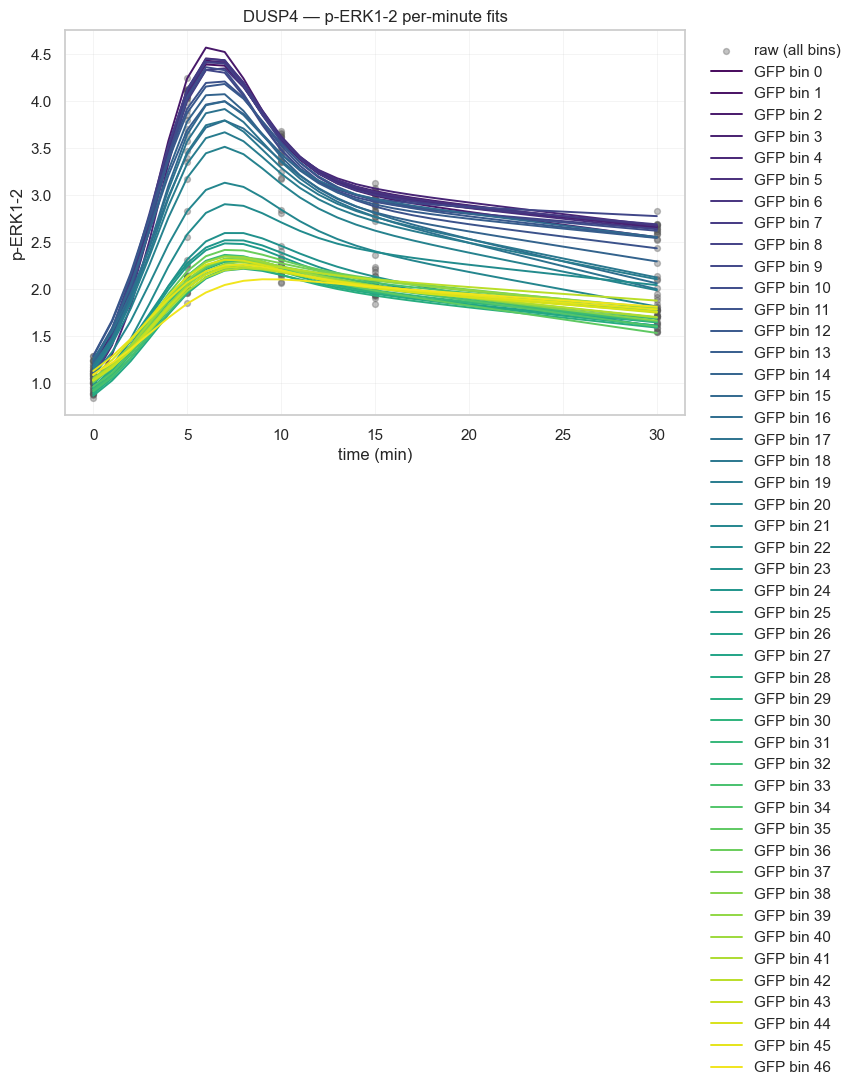

In [16]:
def plot_dense_curves(protein: str) -> None:
    df_dense = dense_fit_long[dense_fit_long["protein"] == protein]
    if df_dense.empty:
        print("No dense fits available for plotting.")
        return
    palette = sns.color_palette("viridis", n_colors=max(len(bin_metadata), 3))
    color_map = {bin_id: palette[i % len(palette)] for i, bin_id in enumerate(sorted(bin_metadata.keys()))}
    fig, ax = plt.subplots(figsize=(8, 5))
    raw_slice = raw_long[raw_long["protein"] == protein]
    if not raw_slice.empty:
        ax.scatter(raw_slice["timepoint"], raw_slice["signal"], color="#555555", alpha=0.35, s=18, label="raw (all bins)")
    for bin_id, sub in df_dense.groupby("GFP_bin"):
        sub = sub.sort_values("timepoint")
        ax.plot(
            sub["timepoint"],
            sub["fit"],
            color=color_map.get(bin_id, "#333333"),
            linewidth=1.4,
            label=f"GFP bin {int(bin_id)}",
        )
    ax.set_title(f"{MARKER_OF_INTEREST} — {protein} per-minute fits")
    ax.set_xlabel("time (min)")
    ax.set_ylabel(protein)
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    fig.tight_layout()
    plt.show()

plot_dense_curves(PLOT_PROTEIN)


/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_21848/1555923385.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


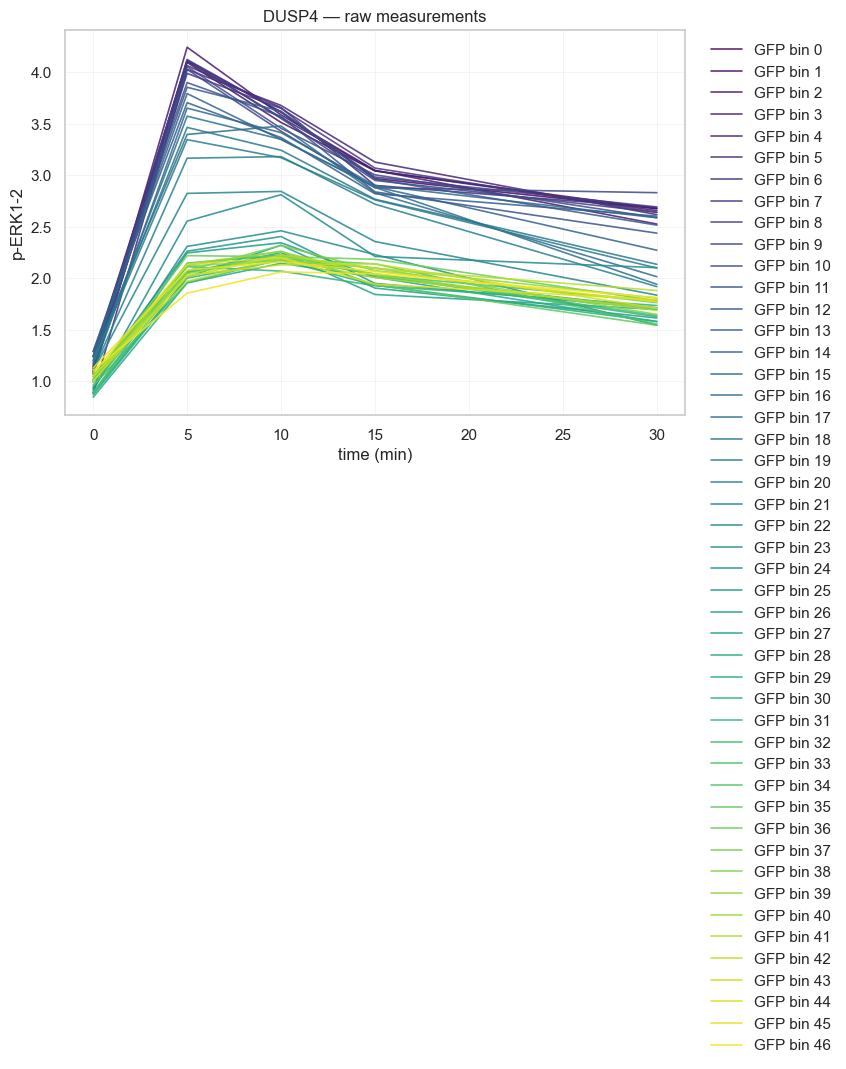

In [17]:
def plot_raw_traces(protein: str) -> None:
    df_raw = raw_long[raw_long["protein"] == protein]
    if df_raw.empty:
        print("No raw traces available.")
        return
    palette = sns.color_palette("viridis", n_colors=max(len(bin_metadata), 3))
    color_map = {bin_id: palette[i % len(palette)] for i, bin_id in enumerate(sorted(bin_metadata.keys()))}
    fig, ax = plt.subplots(figsize=(8, 5))
    for bin_id, sub in df_raw.groupby("GFP_bin"):
        sub = sub.sort_values("timepoint")
        ax.plot(
            sub["timepoint"],
            sub["signal"],
            color=color_map.get(bin_id, "#333333"),
            linewidth=1.2,
            alpha=0.85,
            label=f"GFP bin {int(bin_id)}",
        )
    ax.set_title(f"{MARKER_OF_INTEREST} — raw measurements")
    ax.set_xlabel("time (min)")
    ax.set_ylabel(protein)
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    fig.tight_layout()
    plt.show()

plot_raw_traces(PLOT_PROTEIN)


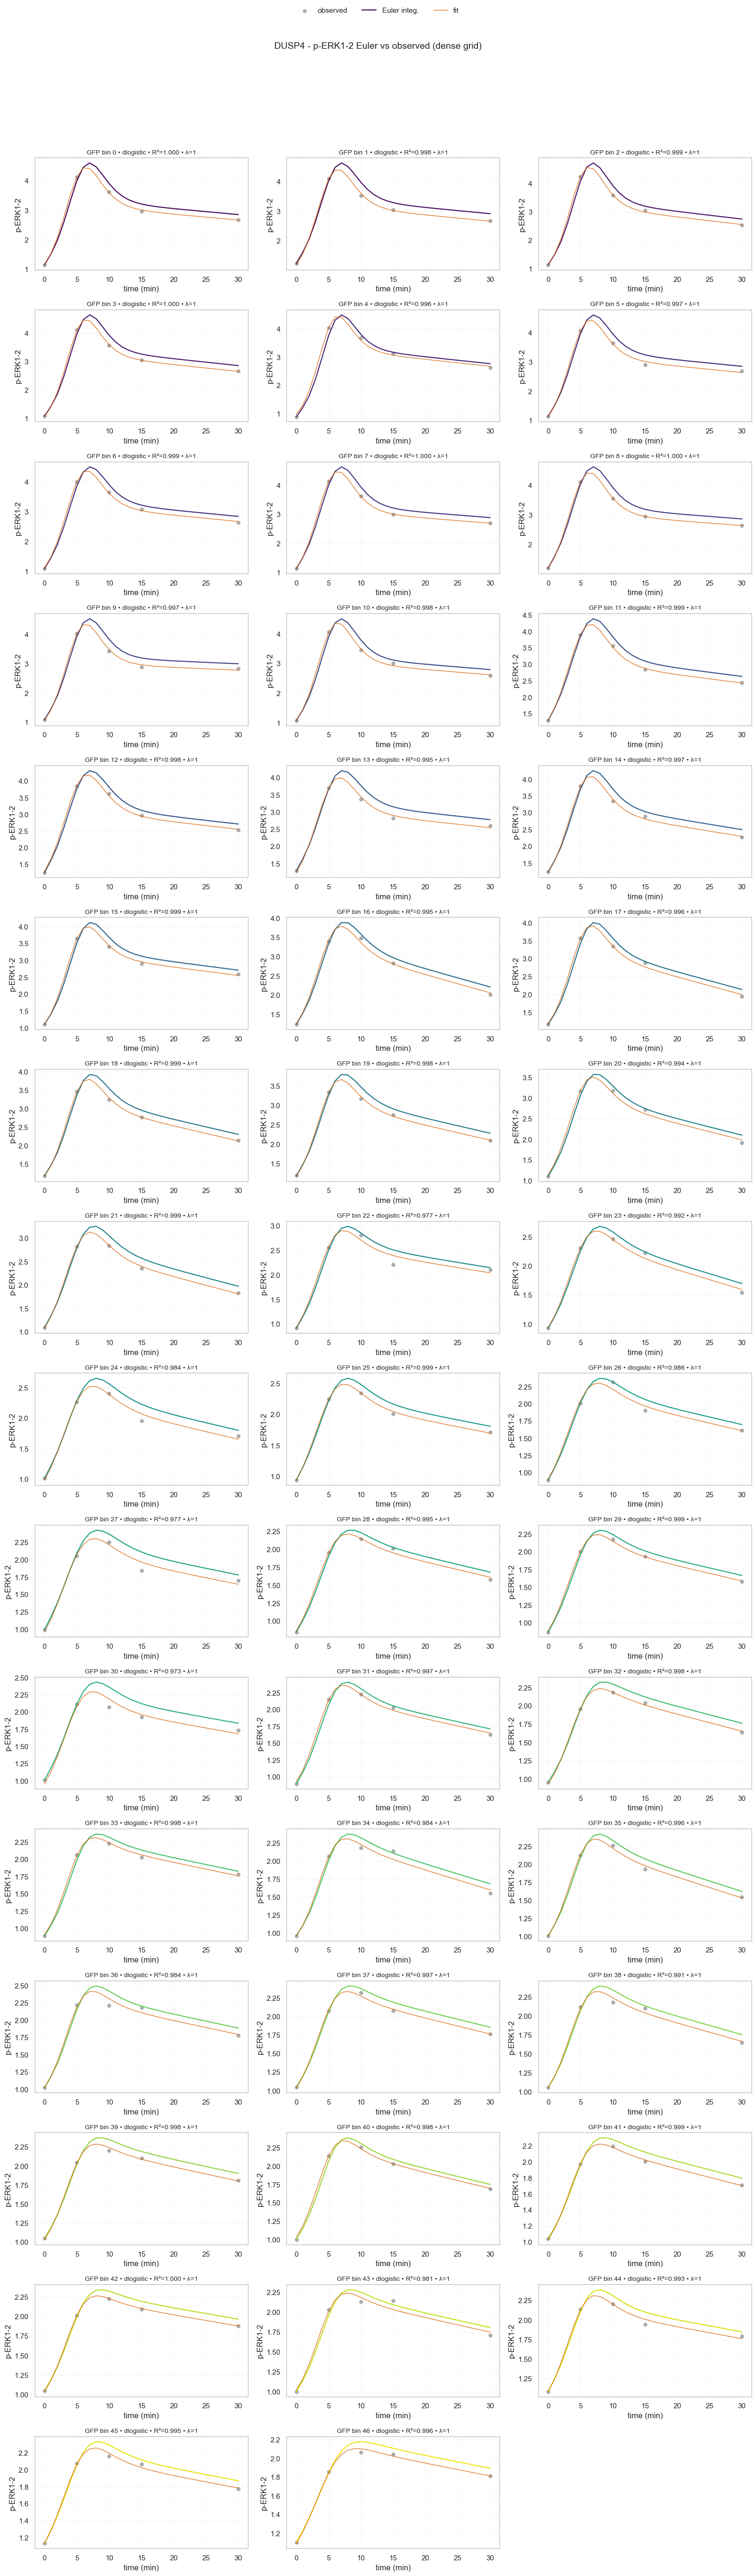

In [18]:
def plot_euler_reconstruction(protein: str, bins: List[int] | None = None) -> None:
    df_raw = raw_long[raw_long['protein'] == protein]
    df_dense = dense_fit_long[dense_fit_long['protein'] == protein]
    if df_dense.empty:
        print('No dense fits available for plotting.')
        return
    if df_raw.empty:
        print('No raw data available.')
        return

    selected_bins = sorted(bins if bins is not None else bin_metadata.keys())
    if not selected_bins:
        print('No fitted bins available.')
        return

    ncols = min(3, len(selected_bins))
    nrows = int(np.ceil(len(selected_bins) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.6 * ncols, 3.6 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    palette = sns.color_palette('viridis', n_colors=max(len(selected_bins), 3))
    color_map = {bin_id: palette[i % len(palette)] for i, bin_id in enumerate(selected_bins)}

    for ax, bin_id in zip(axes_flat, selected_bins):
        raw_bin = df_raw[df_raw['GFP_bin'] == bin_id].sort_values('timepoint')
        dense_bin = df_dense[df_dense['GFP_bin'] == bin_id].sort_values('timepoint')
        ax.set_title(format_bin_label(int(bin_id), protein), fontsize=10)
        ax.set_xlabel('time (min)')
        ax.set_ylabel(protein)
        ax.grid(True, alpha=0.3, linewidth=0.5)

        if raw_bin.empty or dense_bin.empty:
            ax.text(0.5, 0.5, 'no data', transform=ax.transAxes, ha='center', va='center')
            continue

        ax.scatter(raw_bin['timepoint'], raw_bin['signal'], color='#7f7f7f', s=24, alpha=0.6, label='observed')

        times = dense_bin['timepoint'].to_numpy(float)
        fits = dense_bin['fit'].to_numpy(float)
        if len(times) < 2:
            ax.plot(times, fits, color=color_map.get(bin_id, '#333333'), linewidth=1.4, label='fit')
            continue

        deriv_est = np.gradient(fits, times)

        start_t = float(raw_bin['timepoint'].min())
        mask = times >= start_t
        times_use = times[mask]
        deriv_use = deriv_est[mask]
        if times_use.size < 2:
            ax.plot(times, fits, color=color_map.get(bin_id, '#333333'), linewidth=1.4, label='fit')
            continue

        if (raw_bin['timepoint'] == start_t).any():
            y0 = float(raw_bin.loc[raw_bin['timepoint'] == start_t, 'signal'].iloc[0])
        else:
            y0 = float(raw_bin.iloc[0]['signal'])

        dt = np.diff(times_use)
        y_int = np.concatenate([[y0], y0 + np.cumsum(dt * deriv_use[:-1])])

        ax.plot(times_use, y_int, color=color_map.get(bin_id, '#333333'), linewidth=1.6, label='Euler integ.')
        ax.plot(times, fits, color='#d95f02', linewidth=1.0, alpha=0.85, label='fit')

    for ax in axes_flat[len(selected_bins):]:
        ax.set_visible(False)

    handles, labels = axes_flat[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.995))
    fig.suptitle(f"{MARKER_OF_INTEREST} - {protein} Euler vs observed (dense grid)", fontsize=14)
    fig.tight_layout(rect=(0.02, 0.05, 0.98, 0.95))
    plt.show()

plot_euler_reconstruction(PLOT_PROTEIN)


### Notes
- The model set and optimiser match the production pipeline exactly: only `dlogistic` and `rise_fall` are evaluated, each with SciPy's `least_squares(loss='huber', f_scale=1.0, method='trf', max_nfev=400)`.
- Adjust `MARKER_OF_INTEREST`, `SELECTED_BINS`, or the config block above to explore other markers while keeping parity with the pipeline.
- If you want to experiment with additional model families, extend `PREDICTORS` and `INIT_FUNCS`, but remember that the default behaviour here mirrors the released preprocessing script.